In [47]:
from sklearn.model_selection import train_test_split

In [48]:
import pandas as pd
df=pd.read_csv("Ice_cream selling data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [49]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [50]:
import matplotlib.pyplot as plt

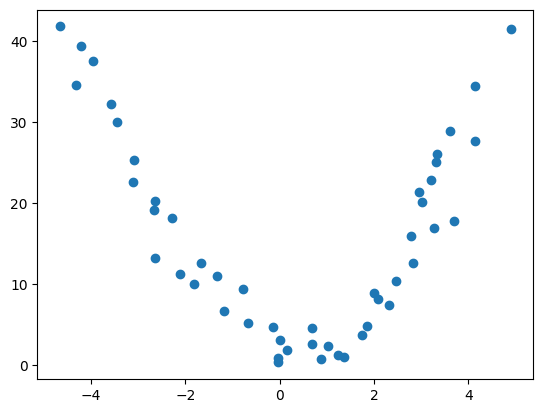

In [51]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])

TRAIN TEST SPLIT

In [52]:
y = df['Ice Cream Sales (units)']
x = df[['Temperature (°C)']]
xtrain,xtest , ytrain , ytest = train_test_split (x,y,train_size = 0.8 , random_state=42)

MODEL CREATION AND TRAINING

In [53]:
from sklearn.linear_model import LinearRegression
model=LinearRegression() 
model.fit(xtrain , ytrain)#learns the pattern from xtrain and ytrain

LinearRegression()

MODEL EVALUATION

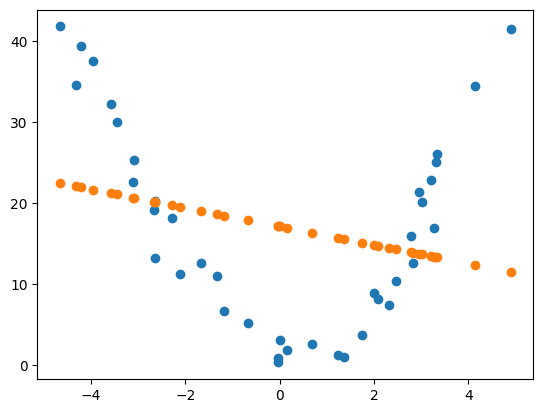

In [54]:
#scatter plot
ypred_train=model.predict(xtrain)
plt.scatter(xtrain,ytrain)
plt.scatter(xtrain,ypred_train)

metrics

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score

In [56]:
train_score = r2_score (ytrain,ypred_train)
print(train_score)

0.06579063815950037


polynomial feature

In [57]:
from sklearn.preprocessing import PolynomialFeatures

In [58]:
poly = PolynomialFeatures(degree=2)

In [59]:
updated_xtrain = poly.fit_transform(xtrain)
updated_xtest =  poly.transform(xtest)
model.fit(updated_xtrain,ytrain)

LinearRegression()

In [60]:
model = LinearRegression()
model.fit(updated_xtrain , ytrain)

LinearRegression()

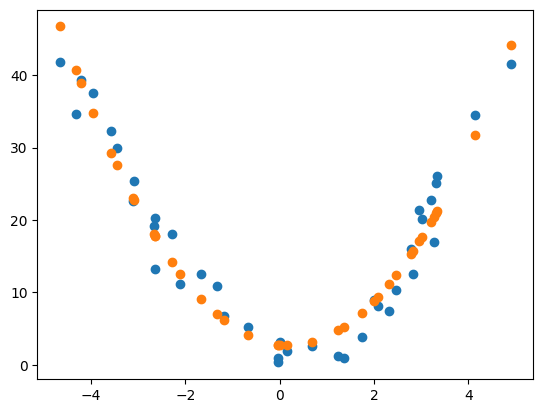

In [61]:
ypred_train=model.predict(updated_xtrain)
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1],ypred_train)

r2_score :-

for degree = 2
Test score : 0.843055137193884
Test score : 0.9413665676490518

for degree = 3
Test score : 0.8405107685716915
Test score : 0.9469116778215552

for degree = 4
Test score : 0.8054468908427623   Test score : 0.9590068634754769


In [62]:
#test score
ypred_test = model.predict(updated_xtest)
test_score = r2_score(ytest,ypred_test)
print(f'test score : {test_score}')

test score : 0.843055137193884


In [63]:
ypred_train = model.predict(updated_xtrain)
test_score = r2_score(ytrain,ypred_train)
print(f'test score : {test_score}')

test score : 0.9413665676490518


for mae:-

for degree = 2 Test score(test) : 3.2299819836597274 Test score(train) : 2.5993732834161136

for degree = 3 Test score(test) : 3.228121129776889 Test score(train) : 2.43566416014849

for degree = 4 Test score(test) : 3.43761854085144   Test score(train) : 2.0963498651499717





In [64]:
#test score
ypred_test = model.predict(updated_xtest)
test_score = mean_absolute_error(ytest,ypred_test)
print(f'Test score : {test_score}')

Test score : 3.2299819836597274


In [65]:
ypred_train = model.predict(updated_xtrain)
test_score = mean_absolute_error(ytrain,ypred_train)
print(f'Test score : {test_score}')

Test score : 2.5993732834161136


for rmse :-

for degree = 2 : Test score(test) : 3.857304297171988 Test score(train) : 2.99931118717202

for degree = 3 : Test score(test) : 3.888445634341502 Test score(train) : 2.8539631962901724

for degree = 4 : Test score(test) : 4.29466642062525  Test score(train) : 2.507866665138919


In [66]:
#test score
ypred_test = model.predict(updated_xtest)
test_score = root_mean_squared_error(ytest,ypred_test)
print(f'Test score : {test_score}')

Test score : 3.857304297171988


In [67]:
ypred_train = model.predict(updated_xtrain)
test_score = root_mean_squared_error(ytrain,ypred_train)
print(f'Test score : {test_score}')

Test score : 2.99931118717202


********